In [1]:
from pyns.nsfile import NSFile
from pathlib import Path
import numpy as np
import pandas as pd
import smile_extract
import matplotlib.pyplot as plt
import seaborn as sns
from src.process_ripple import compose_ripple_smile

In [2]:
monkey = "Prez"
date = "2025-12-11"
task = "memory-guided-reach-stim"
folder = Path(f"/Users/raeed/Library/CloudStorage/OneDrive-UniversityofPittsburgh/0-projects/miso-setup/data/{monkey}/{date}")
nev_filename = folder / f"{monkey}_{date}_{task}_neural.nev"
smile_file = folder / f"{monkey}_{date}_{task}_behavior.mat"
nsfile = NSFile(str(nev_filename))
smile_data = smile_extract.direct_load_smile_data(str(smile_file))

In [3]:
trialframe = compose_ripple_smile(
    nsfile,
    smile_data,
    bin_size='1ms',
    monkey=monkey,
    start_target_name='touchbarcircle',
    end_target_name='reachtargettouchbarmg',
)
trialframe

/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  return pd.concat(
/Users/raeed/codebase/0-projects/smile-extraction/smile_extract/composition.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

signal                                                                                                  neural activity  \
channel                                                                                                      M1.chan033   
trial_id time                   stim trial result  target direction state            stimulated channel                   
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)                     0   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)                     0   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (M1.chan036)                     0   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (M1.chan036)                     0   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (M1.chan036)                     0   
...                                                                                                                 ...   
721      0 days 00:00:06.502000 True       failure 180              Failure (Center) ()                               0   
         0 days 00:00:06.503000 True       failure 180              Failure (Center) ()                               0   
         0 days 00:00:06.504000 True       failure 180              Failure (Center) ()                               0   
         0 days 00:00:06.505000 True       failure 180              Failure (Center) ()                               0   
         0 days 00:00:06.506000 True       failure 180              end              ()                               0   

signal                                                                                                              \
channel                                                                                                 M1.chan034   
trial_id time                   stim trial result  target direction state            stimulated channel              
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.002000 True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.003000 True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.004000 True       failure 180              Reach to Center  (M1.chan036)                0   
...                                                                                                            ...   
721      0 days 00:00:06.502000 True       failure 180              Failure (Center) ()                          0   
         0 days 00:00:06.503000 True       failure 180              Failure (Center) ()                          0   
         0 days 00:00:06.504000 True       failure 180              Failure (Center) ()                          0   
         0 days 00:00:06.505000 True       failure 180              Failure (Center) ()                          0   
         0 days 00:00:06.506000 True       failure 180              end              ()                          0   

signal                                                                                                              \
channel                                                                                                 M1.chan035   
trial_id time                   stim trial result  target direction state            stimulated channel              
1        0 days 00:00:00        True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.001000 True       failure 180              Reach to Center  (M1.chan036)                0   
         0 days 00:00:00.002000 Tr

In [4]:
neural_data = (
    pd.DataFrame(trialframe['neural activity'])
    .rename_axis('recorded channel',axis=1)
    .sort_index(axis=1)
)

pass
False    88
True     40
Name: count, dtype: int64

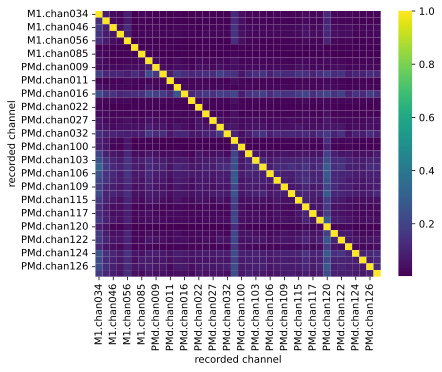

In [5]:
from src.process_ripple import get_channel_stats
spike_mat = (
    neural_data
    .xs(level='stim trial',key=False)
)
channel_stats = get_channel_stats(spike_mat, max_fano=1000, max_coincidence=0.5)
spike_mat_select = (
    spike_mat
    .loc[:, channel_stats.index[channel_stats['pass']]]
    .fillna(0) # sometimes there's missing data, maybe from some packet drops in Trellis?
)
select_coincidence = (
    (spike_mat_select.T @ spike_mat_select)
    / spike_mat_select.sum(axis=0)
)
sns.heatmap(select_coincidence, cmap='viridis')
channel_stats['pass'].value_counts()

In [ ]:
from src.time_slice import get_epoch_data,multivalue_xs
hand_data = trialframe['hand position']
movement = (
    hand_data
    .xs(level='result',key='success')
    .pipe(multivalue_xs,level='stimulated channel',keys=[frozenset(),frozenset({'PMd.chan010'})])
    .pipe(get_epoch_data,epochs={
        'peri-go': ('Cheat Period',slice(pd.to_timedelta('-100ms'),pd.to_timedelta('1000ms'))),
    })
)

import altair as alt
alt.data_transformers.enable('json')
base_chart = (
    alt.Chart(
        movement
        .stack()
        .rename('position')
        .reset_index()
        .assign(
            time=lambda df: df['time'].dt.total_seconds(),
        )
        .assign(**{
            'stimulated channel': lambda df: df['stimulated channel'].map(lambda x: str(set(x)).strip("{}").replace("'", "   ").replace(", "," ").replace("M1","  M1")),
        })
    )
    # .configure_axis(grid=False)
    # .configure_view(stroke=None)
)
traces = (
    base_chart
    .mark_errorband(extent='ci')
    .encode(
        x='time:Q',
        y=alt.Y('position:Q',scale=alt.Scale(zero=False)),
        # detail='trial_id:O',
        color=alt.Color('stimulated channel:N',sort=['PMd.chan010','set()']),
    )
)

stim_boundary = (
    base_chart
    .mark_rule(color='purple',strokeDash=[4,4])
    .encode(
        y=alt.value(30),
    )
)

(
    traces
    .facet(
        row='target direction:N',
        column='channel:N',
    )
    .configure_axis(grid=False)
    .configure_view(stroke=None)
)

alt.FacetChart(...)

In [53]:
movement.stack()

trial_id  time                      stim trial  target direction  state    stimulated channel  phase    channel
19        -1 days +23:59:59.750000  False       180               memory   ()                  peri-go  x           79.013334
                                                                                                        y          899.922806
                                                                                                        z          -14.524813
          -1 days +23:59:59.751000  False       180               memory   ()                  peri-go  x           79.014238
                                                                                                        y          899.921663
                                                                                                                      ...    
679       0 days 00:00:00.911000    False       180               Success  ()                  peri-go  y          894.186447
      